In [1]:
from qiskit import __version__
print(__version__)

2.4.1


# Importing Packages

In [2]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, state_fidelity, Pauli, DensityMatrix, partial_trace
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit_aer.library import SaveDensityMatrix, SaveStatevector, SetDensityMatrix
from qiskit import transpile 
import numpy as np
from qiskit_aer.noise import NoiseModel, depolarizing_error, ReadoutError
from qiskit.circuit.library import HGate, UnitaryGate, IGate
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, NullFormatter
import matplotlib.ticker as mticker
from matplotlib.gridspec import GridSpec
from scipy.optimize import curve_fit

# Graphing Settings

In [3]:
mpl.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.size': 8,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'legend.fontsize': 8,
    'lines.linewidth': 1.2,
    'figure.dpi': 150,
})

# Importing Data

In [4]:
data1 = np.load("depolarizing/depolarizing_error_rates.npz")
data2 = np.load("convergence_axis/convergence_axis_error_rates.npz")

depol_one_qubit_gate_error_prob = data1["one_qubit_gate_error_prob"]
depol_optimal_output_error_rate = data1["optimal_output_error_rate"]
depol_ideal_output_error_rate = data1["ideal_output_error_rate"]
depol_ideal_output_error_rate_unc = data1["ideal_output_error_rate_unc"]
depol_two_q_output_error_rate = data1["two_q_output_error_rate"]
depol_two_q_output_error_rate_unc = data1["two_q_output_error_rate_unc"]
depol_one_q_output_error_rate = data1["one_q_output_error_rate"]
depol_one_q_output_error_rate_unc = data1["one_q_output_error_rate_unc"]
depol_meas_output_error_rate = data1["meas_output_error_rate"]
depol_meas_output_error_rate_unc = data1["meas_output_error_rate_unc"]
depol_all_output_error_rate = data1["all_output_error_rate"]
depol_all_output_error_rate_unc = data1["all_output_error_rate_unc"]
depol_one_qubit_contributions = data1["one_qubit_contributions"]
depol_two_qubit_contributions = data1["two_qubit_contributions"]
depol_measurement_contributions = data1["measurement_contributions"]


conv_one_qubit_gate_error_prob = data2["one_qubit_gate_error_prob"]
conv_optimal_output_error_rate = data2["optimal_output_error_rate"]
conv_ideal_output_error_rate = data2["ideal_output_error_rate"]
conv_ideal_output_error_rate_unc = data2["ideal_output_error_rate_unc"]
conv_two_q_output_error_rate = data2["two_q_output_error_rate"]
conv_two_q_output_error_rate_unc = data2["two_q_output_error_rate_unc"]
conv_one_q_output_error_rate = data2["one_q_output_error_rate"]
conv_one_q_output_error_rate_unc = data2["one_q_output_error_rate_unc"]
conv_meas_output_error_rate = data2["meas_output_error_rate"]
conv_meas_output_error_rate_unc = data2["meas_output_error_rate_unc"]
conv_all_output_error_rate = data2["all_output_error_rate"]
conv_all_output_error_rate_unc = data2["all_output_error_rate_unc"]
conv_one_qubit_contributions = data2["one_qubit_contributions"]
conv_two_qubit_contributions = data2["two_qubit_contributions"]
conv_measurement_contributions = data2["measurement_contributions"]

# Plots

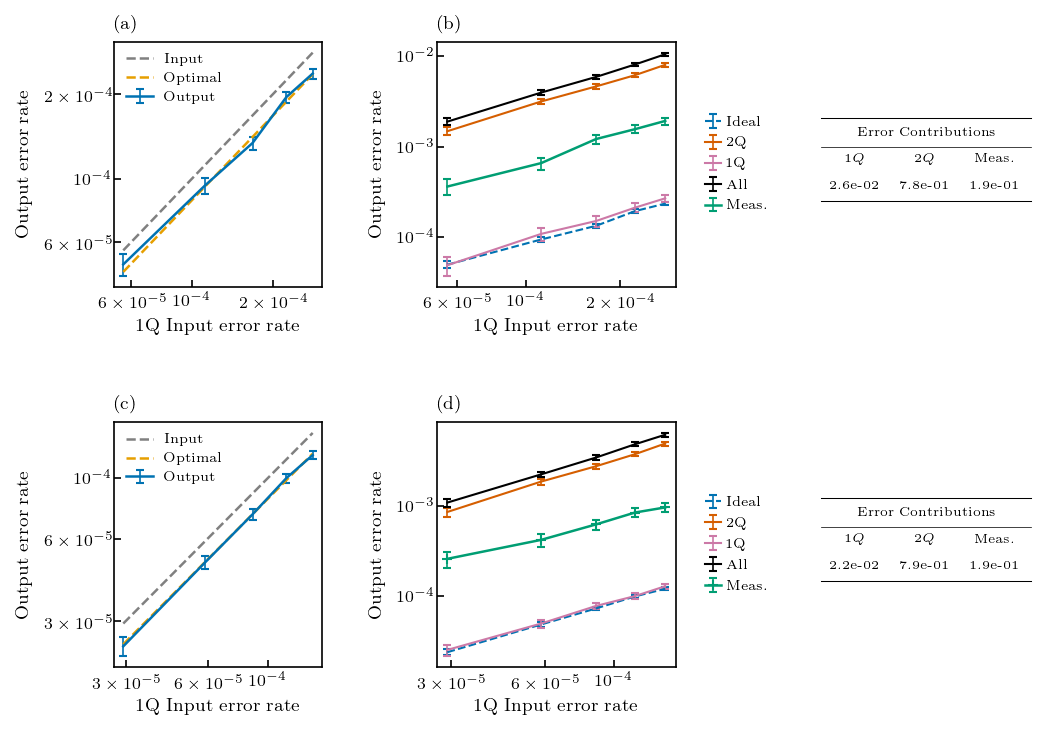

In [5]:
def format_log_axes(ax, xticks, xticklabels, yticks=None, yticklabels=None):
    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticklabels)

    if yticks is not None:
        ax.set_yticks(yticks)
    else:
        ax.set_yticks(xticks)

    if yticklabels is not None:
        ax.set_yticklabels(yticklabels)
    else:
        ax.set_yticklabels(xticklabels)

    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.xaxis.set_minor_formatter(mticker.NullFormatter())
    ax.yaxis.set_minor_locator(mticker.NullLocator())
    ax.yaxis.set_minor_formatter(mticker.NullFormatter())

    ax.tick_params(which="both", direction="in", top=False, right=False)
    ax.tick_params(axis="y", which="both", pad=1)
    ax.yaxis.labelpad = 1


def draw_error_contribution_table(ax_table, values):
    ax_table.axis("off")
    ax_table.set_xlim(0, 1)
    ax_table.set_ylim(0, 1)

    headers = [r"$1Q$", r"$2Q$", r"Meas."]

    x0 = 0.02
    y0 = 0.35
    width = 0.96
    height = 0.34
    col_w = width / 3

    y_title = y0 + 0.82 * height
    y_header = y0 + 0.50 * height
    y_values = y0 + 0.18 * height

    y_top = y0 + height
    y_mid = y0 + 0.65 * height
    y_bottom = y0

    fs_title = 6.2
    fs_body = 5.8

    ax_table.text(
        x0 + width / 2,
        y_title,
        "Error Contributions",
        ha="center",
        va="center",
        fontsize=fs_title,
        fontweight="semibold",
        transform=ax_table.transAxes,
    )

    ax_table.plot(
        [x0, x0 + width],
        [y_top, y_top],
        color="black",
        linewidth=0.5,
        transform=ax_table.transAxes,
        clip_on=False,
    )

    ax_table.plot(
        [x0, x0 + width],
        [y_mid, y_mid],
        color="black",
        linewidth=0.35,
        transform=ax_table.transAxes,
        clip_on=False,
    )

    ax_table.plot(
        [x0, x0 + width],
        [y_bottom, y_bottom],
        color="black",
        linewidth=0.5,
        transform=ax_table.transAxes,
        clip_on=False,
    )

    for j, header in enumerate(headers):
        x = x0 + (j + 0.5) * col_w

        ax_table.text(
            x,
            y_header,
            header,
            ha="center",
            va="center",
            fontsize=fs_body,
            transform=ax_table.transAxes,
        )

        ax_table.text(
            x,
            y_values,
            values[j],
            ha="center",
            va="center",
            fontsize=fs_body,
            transform=ax_table.transAxes,
        )


# ==========================================================
# Figure layout
# ==========================================================

fig = plt.figure(figsize=(6.75, 4.85))

gs = GridSpec(
    2,
    6,
    figure=fig,
    width_ratios=[1.0, 0.52, 1.15, 0.55, 0.08, 1.05],
    height_ratios=[1.0, 1.0],
    wspace=0.02,
    hspace=0.55,
)

# Top row: depolarizing noise
ax_a = fig.add_subplot(gs[0, 0])
ax_spacer_top_1 = fig.add_subplot(gs[0, 1])
ax_b = fig.add_subplot(gs[0, 2])
ax_leg_top = fig.add_subplot(gs[0, 3])
ax_spacer_top_2 = fig.add_subplot(gs[0, 4])
ax_table_top = fig.add_subplot(gs[0, 5])

# Bottom row: convergence-axis noise
ax_c = fig.add_subplot(gs[1, 0])
ax_spacer_bot_1 = fig.add_subplot(gs[1, 1])
ax_d = fig.add_subplot(gs[1, 2])
ax_leg_bot = fig.add_subplot(gs[1, 3])
ax_spacer_bot_2 = fig.add_subplot(gs[1, 4])
ax_table_bot = fig.add_subplot(gs[1, 5])

for ax in [
    ax_spacer_top_1,
    ax_spacer_top_2,
    ax_leg_top,
    ax_table_top,
    ax_spacer_bot_1,
    ax_spacer_bot_2,
    ax_leg_bot,
    ax_table_bot,
]:
    ax.axis("off")


# ==========================================================
# Tick labels
# ==========================================================

depol_xticks = [6e-5, 1e-4, 2e-4]
depol_xticklabels = [
    r"$6\times10^{-5}$",
    r"$10^{-4}$",
    r"$2\times10^{-4}$",
]

depol_y1ticks = depol_xticks
depol_y1ticklabels = depol_xticklabels

depol_y2ticks = [1e-4, 1e-3, 1e-2]
depol_y2ticklabels = [
    r"$10^{-4}$",
    r"$10^{-3}$",
    r"$10^{-2}$",
]

conv_xticks = [3e-5, 6e-5, 1e-4]
conv_xticklabels = [
    r"$3\times10^{-5}$",
    r"$6\times10^{-5}$",
    r"$10^{-4}$",
]

conv_y1ticks = conv_xticks
conv_y1ticklabels = conv_xticklabels

conv_y2ticks = [1e-4, 1e-3]
conv_y2ticklabels = [
    r"$10^{-4}$",
    r"$10^{-3}$",
]


# ==========================================================
# Top row: depolarizing noise
# ==========================================================

# ── Panel (a): ideal output vs input ───────────────────────
ax_a.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_ideal_output_error_rate,
    yerr=depol_ideal_output_error_rate_unc,
    color="#0072B2",
    linestyle="-",
    capsize=2,
    elinewidth=0.8,
    label="Output",
)

ax_a.plot(
    depol_one_qubit_gate_error_prob,
    depol_one_qubit_gate_error_prob,
    color="gray",
    linestyle="--",
    label="Input",
)

ax_a.plot(
    depol_one_qubit_gate_error_prob,
    depol_optimal_output_error_rate,
    color='#E69F00',
    linestyle="--",
    label="Optimal"
)

format_log_axes(
    ax_a,
    depol_xticks,
    depol_xticklabels,
    depol_y1ticks,
    depol_y1ticklabels,
)

ax_a.yaxis.labelpad = 6
ax_a.legend(frameon=False, loc="upper left", fontsize=6.5)
ax_a.set_ylabel("Output error rate")
ax_a.set_xlabel("1Q Input error rate")
ax_a.set_title("(a)", loc="left", fontsize=9)


# ── Panel (b): component noise comparison ──────────────────
ax_b.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_ideal_output_error_rate,
    yerr=depol_ideal_output_error_rate_unc,
    color="#0072B2",
    linestyle="--",
    linewidth=1.0,
    capsize=2,
    elinewidth=0.8,
    label="Ideal",
)

ax_b.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_two_q_output_error_rate,
    yerr=depol_two_q_output_error_rate_unc,
    color="#D55E00",
    linestyle="-",
    linewidth=1.0,
    capsize=2,
    elinewidth=0.8,
    label="2Q",
)

ax_b.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_one_q_output_error_rate,
    yerr=depol_one_q_output_error_rate_unc,
    color="#CC79A7",
    linestyle="-",
    linewidth=1.0,
    capsize=2,
    elinewidth=0.8,
    label="1Q",
)

ax_b.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_all_output_error_rate,
    yerr=depol_all_output_error_rate_unc,
    color="#000000",
    linestyle="-",
    linewidth=1.0,
    capsize=2,
    elinewidth=0.8,
    label="All",
)

ax_b.errorbar(
    depol_one_qubit_gate_error_prob,
    depol_meas_output_error_rate,
    yerr=depol_meas_output_error_rate_unc,
    fmt="-",
    color="#009E73",
    capsize=2,
    markersize=5,
    elinewidth=0.8,
    label="Meas.",
)

format_log_axes(
    ax_b,
    depol_xticks,
    depol_xticklabels,
    depol_y2ticks,
    depol_y2ticklabels,
)

ax_b.yaxis.labelpad = 6
ax_b.set_ylabel("Output error rate")
ax_b.set_xlabel("1Q Input error rate")
ax_b.set_title("(b)", loc="left", fontsize=9)

handles_top, labels_top = ax_b.get_legend_handles_labels()

ax_leg_top.legend(
    handles_top,
    labels_top,
    loc="center",
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.65,
    borderaxespad=0.0,
)

depol_table_values = [
    f"{depol_one_qubit_contributions:.1e}",
    f"{depol_two_qubit_contributions:.1e}",
    f"{depol_measurement_contributions:.1e}",
]

draw_error_contribution_table(ax_table_top, depol_table_values)


# ==========================================================
# Bottom row: convergence-axis noise
# ==========================================================

# ── Panel (c): ideal output vs input ───────────────────────
ax_c.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_ideal_output_error_rate,
    yerr=conv_ideal_output_error_rate_unc,
    color="#0072B2",
    linestyle="-",
    capsize=2,
    elinewidth=0.8,
    label="Output",
)

ax_c.plot(
    conv_one_qubit_gate_error_prob,
    conv_one_qubit_gate_error_prob,
    color="gray",
    linestyle="--",
    label="Input",
)

ax_c.plot(
    conv_one_qubit_gate_error_prob,
    conv_optimal_output_error_rate,
    color='#E69F00',
    linestyle="--",
    label="Optimal"
)

format_log_axes(
    ax_c,
    conv_xticks,
    conv_xticklabels,
    conv_y1ticks,
    conv_y1ticklabels,
)

ax_c.yaxis.labelpad = 6
ax_c.legend(frameon=False, loc="upper left", fontsize=6.5)
ax_c.set_ylabel("Output error rate")
ax_c.set_xlabel("1Q Input error rate")
ax_c.set_title("(c)", loc="left", fontsize=9)


# ── Panel (d): component noise comparison ──────────────────
ax_d.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_ideal_output_error_rate,
    yerr=conv_ideal_output_error_rate_unc,
    color="#0072B2",
    linestyle="--",
    linewidth=1.0,
    capsize=2,
    elinewidth=0.8,
    label="Ideal",
)

ax_d.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_two_q_output_error_rate,
    yerr=conv_two_q_output_error_rate_unc,
    color="#D55E00",
    linestyle="-",
    linewidth=1.0,
    capsize=2,
    elinewidth=0.8,
    label="2Q",
)

ax_d.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_one_q_output_error_rate,
    yerr=conv_one_q_output_error_rate_unc,
    color="#CC79A7",
    linestyle="-",
    linewidth=1.0,
    capsize=2,
    elinewidth=0.8,
    label="1Q",
)

ax_d.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_all_output_error_rate,
    yerr=conv_all_output_error_rate_unc,
    color="#000000",
    linestyle="-",
    linewidth=1.0,
    capsize=2,
    elinewidth=0.8,
    label="All",
)

ax_d.errorbar(
    conv_one_qubit_gate_error_prob,
    conv_meas_output_error_rate,
    yerr=conv_meas_output_error_rate_unc,
    fmt="+-",
    color="#009E73",
    capsize=2,
    markersize=5,
    elinewidth=0.8,
    label="Meas.",
)

format_log_axes(
    ax_d,
    conv_xticks,
    conv_xticklabels,
    conv_y2ticks,
    conv_y2ticklabels,
)

ax_d.yaxis.labelpad = 6
ax_d.set_ylabel("Output error rate")
ax_d.set_xlabel("1Q Input error rate")
ax_d.set_title("(d)", loc="left", fontsize=9)

handles_bot, labels_bot = ax_d.get_legend_handles_labels()

ax_leg_bot.legend(
    handles_bot,
    labels_bot,
    loc="center",
    frameon=False,
    fontsize=6.5,
    handlelength=1.2,
    handletextpad=0.35,
    labelspacing=0.65,
    borderaxespad=0.0,
)

conv_table_values = [
    f"{conv_one_qubit_contributions:.1e}",
    f"{conv_two_qubit_contributions:.1e}",
    f"{conv_measurement_contributions:.1e}",
]

draw_error_contribution_table(ax_table_bot, conv_table_values)


# ==========================================================
# Final spacing and export
# ==========================================================

fig.subplots_adjust(
    left=0.08,
    right=0.99,
    bottom=0.10,
    top=0.96,
)

plt.show()